In [1]:
import matplotlib.pyplot as plt
from gluonts.dataset.repository import dataset_recipes

from uni2ts.eval_util.data import get_gluonts_test_dataset
from uni2ts.eval_util.plot import plot_next_multi
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

/home/onyxia/work/DLforTimeSeries/moirai-classification/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/onyxia/work/DLforTimeSeries/moirai-classification/.venv/lib/python3.11/site-packages/uni2ts/common/env.py:43: UserWarning: Failed to load .env file.
  warnings.warn("Failed to load .env file.")


### Settings
SIZE: model size, select the model size of Moirai to perform inference with

CTX: context length, how many time steps the model will take as input for inference

PSZ: patch size, how many time steps to perform patching with

BSZ: batch size, number of samples in each batch for inference

In [2]:
MODEL = "moirai"  # model name: choose from {'moirai', 'moirai-moe', 'moirai2'}
SIZE = "small"  # model size: choose from {'small', 'base', 'large'}
CTX = 1000  # context length: any positive integer
PSZ = 32  # patch size: choose from {"auto", 8, 16, 32, 64, 128}
BSZ = 32  # batch size: any positive integer

### Prepare datasets and model

In [3]:
# List of available datasets:
sorted(dataset_recipes.keys())

['ETTh1',
 'ETTh2',
 'ETTm1',
 'ETTm2',
 'METR_LA',
 'airpassengers',
 'australian_electricity_demand',
 'bitcoin',
 'bitcoin_with_missing',
 'car_parts_with_missing',
 'car_parts_without_missing',
 'cif_2016',
 'cif_2016_12',
 'cif_2016_6',
 'constant',
 'covid_deaths',
 'covid_mobility',
 'dominick',
 'elecdemand',
 'electricity',
 'electricity_hourly',
 'electricity_nips',
 'electricity_weekly',
 'exchange_rate',
 'exchange_rate_nips',
 'extended_web_traffic_with_missing',
 'fred_md',
 'hospital',
 'istanbul_traffic',
 'jena_weather',
 'kaggle_web_traffic_weekly',
 'kaggle_web_traffic_with_missing',
 'kaggle_web_traffic_without_missing',
 'kdd_cup_2018_with_missing',
 'kdd_cup_2018_without_missing',
 'london_smart_meters_with_missing',
 'london_smart_meters_without_missing',
 'm1_monthly',
 'm1_quarterly',
 'm1_yearly',
 'm3_monthly',
 'm3_other',
 'm3_quarterly',
 'm3_yearly',
 'm4_daily',
 'm4_hourly',
 'm4_monthly',
 'm4_quarterly',
 'm4_weekly',
 'm4_yearly',
 'm5',
 'monash_m3_

In [4]:
# Load dataset using loader utils
test_data, metadata = get_gluonts_test_dataset(
    "electricity", prediction_length=None, regenerate=False
)
metadata

MetaData(freq='1H', target_dim=1, prediction_length=24, feat_dynamic_real_dim=0, past_feat_dynamic_real_dim=0, split='test')

In [5]:
# Prepare model
if MODEL == "moirai":
    model = MoiraiForecast(
        module=MoiraiModule.from_pretrained(
            f"Salesforce/moirai-1.1-R-{SIZE}",
        ),
        prediction_length=metadata.prediction_length,
        context_length=CTX,
        patch_size=PSZ,
        num_samples=100,
        target_dim=metadata.target_dim,
        feat_dynamic_real_dim=metadata.feat_dynamic_real_dim,
        past_feat_dynamic_real_dim=metadata.past_feat_dynamic_real_dim,
    )


predictor = model.create_predictor(batch_size=BSZ)
forecasts = predictor.predict(test_data.input)

input_it = iter(test_data.input)
label_it = iter(test_data.label)
forecast_it = iter(forecasts)

In [6]:
model.describe_inputs(1)

InputSpec(data={'past_target': Input(shape=(1, 1000, 1), dtype=torch.float32, required=True), 'past_observed_target': Input(shape=(1, 1000, 1), dtype=torch.bool, required=True), 'past_is_pad': Input(shape=(1, 1000), dtype=torch.bool, required=True)}, zeros_fn=<built-in method zeros of type object at 0x7f197f0d4980>)

### Make predictions

In [7]:
inp = next(input_it)  # input / lookback window
label = next(label_it)  # label / forecast horizon
forecast = next(forecast_it)  # predictions (GluonTS Forecast object)

In [8]:
inp

{'target': array([14., 18., 21., ...,  6.,  9.,  7.], dtype=float32),
 'start': Period('2012-01-01 00:00', 'H'),
 'feat_static_cat': array([0], dtype=int32),
 'item_id': 0}

In [9]:
label

{'target': array([ 9., 10., 22., 20., 13., 12., 13., 13., 12., 13., 11., 10.,  8.,
        23.,  6.,  2.,  2.,  2.,  4.,  2.,  6.,  8.,  8.,  6.],
       dtype=float32),
 'start': Period('2014-05-26 20:00', 'H'),
 'feat_static_cat': array([0], dtype=int32),
 'item_id': 0}

In [10]:
forecast.samples.shape, forecast.mean_ts.shape

((100, 24), (24,))

In [11]:
inp.keys(), label.keys()

(dict_keys(['target', 'start', 'feat_static_cat', 'item_id']),
 dict_keys(['target', 'start', 'feat_static_cat', 'item_id']))

In [12]:
inp["target"].shape, label["target"].shape

((21044,), (24,))

Moirai produces a _probabilistic forecast_, in the form of a mixture distribution.
```forecast``` is a sample forecast, taking ```num_samples=100``` samples from the mixture distribution per time step.

In [13]:
if MODEL == "moirai2":
    print(forecast.mean)
else:
    print(forecast.samples.shape)

(100, 24)


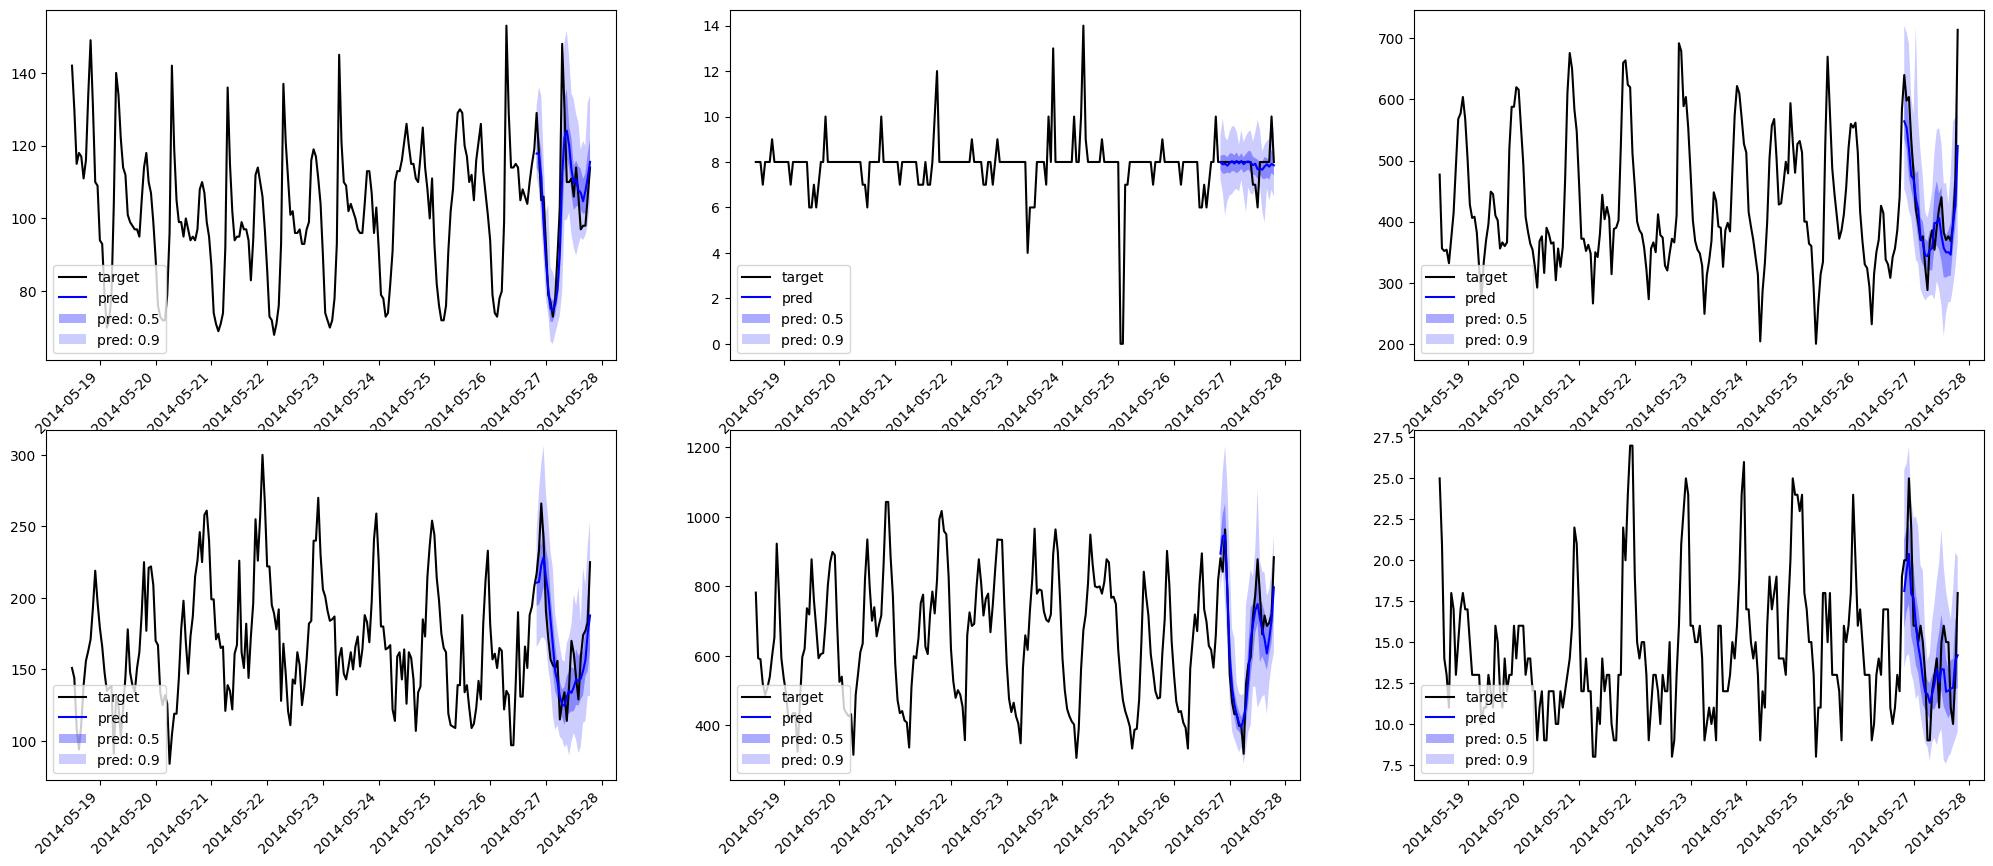

In [14]:
# Visualize forecasts
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 10))
plot_next_multi(
    axes,
    input_it,
    label_it,
    forecast_it,
    context_length=200,
    intervals=(0.5, 0.9),
    dim=None,
    name="pred",
    show_label=True,
)